<a href="https://colab.research.google.com/github/artime123/northstar-databases-analytics/blob/main/notebooks/03_Section3_MongoDB_Atlas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility — Section 3 : MongoDB Atlas (NoSQL)

**Module :** Databases and Analytics  
**Case Study :** NorthStar Urban Mobility and Logistics

## Aim of this notebook
Design and implement a MongoDB Atlas database that fits NorthStar's *operational* reality (not the boilerplate retail schema in the original brief) . Specifically :

1. **Justify NoSQL** for the case study's nested , evolving operational data .
2. **Design a document schema** centred on *journey - level* records that embed events , exceptions and complaints .
3. **Insert** the data programmatically .
4. **Demonstrate CRUD** : 20 queries covering find / insert / update / delete and aggregations .
5. **Optimise** with indexes ; show `explain()` evidence of improvement .
6. Produce **pairwise plots** of MongoDB - derived numerical features .

**Pre-requisite :** complete the Atlas setup (free M0 cluster , user , IP allow - list , connection string) . See `00_MongoDB_Atlas_Setup.md` if not done .

---

## 1 . Why NoSQL for NorthStar ?

The case study explicitly describes nested , fast - changing operational records — " long sequences of messages , repeated status changes , attachments , geolocation references , escalation notes " — that don't fit the existing relational system . A document database fits because :

| Requirement from case study | Relational pain | Document model strength |
|---|---|---|
| Long, variable event histories per journey | needs separate child tables joined every read | array of sub-documents read in a single query |
| Complaint chats, attachments, escalation notes | semi-structured, schema churn | flexible, schema-less per document |
| Exception / status mismatches across systems | requires constant joins to reconcile | one journey = one document, all status transitions visible |
| GPS coordinates, sensor alerts | poor fit for normalised tables | native geospatial indexes |
| Cross-cutting analytical queries | complex joins, slow | aggregation pipeline, optimisable indexes |

**The chosen design pattern is a *journey document* .** One document per order = one row per journey , with deliveries , complaints , incidents , and app events embedded as arrays . This mirrors the operational reality (a customer's perspective of a journey) and lets a single read return everything an ops manager needs to investigate a case .

---

## 2. Schema design — collections in the `northstar` database

We keep slow - changing reference data in their own normalised collections (referenced by id) and embed only what's read together . This is the standard *embed - vs - reference* trade - off applied to NorthStar's actual access patterns .

| Collection | Cardinality | Embedded? | Why |
|---|---|---|---|
| `customers` | 650 | reference | read independently from journeys; profile data slow-changing |
| `drivers` | 170 | reference | shared across many journeys |
| `vehicles` | 120 | reference | shared across many journeys |
| `hubs` | 8 | reference | tiny lookup |
| `journeys` | 1,250 | **embeds** delivery, complaints[], incidents[], app_events[] | one read = full case view |
| `app_events_raw` | 640 | reference | also kept raw for stream-style analytics |

Document shape for `journeys` (illustrative):
```json
{
  "_id": "O00001",
  "customer_id": "C0292",
  "service_type": "Passenger",
  "order_created_at": ISODate("2024-08-20T14:43:00Z"),
  "promised_window_hours": 6,
  "pickup_zone": "Airport",
  "dropoff_zone": "South",
  "priority_level": "Medium",
  "order_value": 126.65,
  "booking_channel": "App",
  "delivery": { "delivery_id":"DL00123", "driver_id":"D004",
                "vehicle_id":"V056", "hub_id":"H05",
                "dispatch_time":..., "completed_at":...,
                "status":"Delayed", "route_distance_km":17.3,
                "manual_route_override_count":2,
                "customer_rating_post_delivery":3.0 },
  "complaints":  [ { "complaint_id":"CP0123", "type":"Delay",
                     "channel":"App", "severity":"High",
                     "created_at":..., "status":"Open",
                     "compensation_amount":23.99 } ],
  "incidents":   [ { "incident_id":"I0019", "type":"BatteryAlert",
                     "severity":"Medium",
                     "resolution_status":"Escalated" } ],
  "app_events":  [ { "event_id":"AE0099", "type":"chat_escalated",
                     "timestamp":..., "latency_ms":420, "success":1 } ]
}
```

This schema is **driven by NorthStar's analytical needs** , not by mechanical translation of the source CSVs .

## 3 . Connect to Atlas

In [1]:
!pip install -q pymongo pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.8 MB/s eta 0:00:00


In [2]:
from pymongo import MongoClient, ASCENDING, DESCENDING
from getpass import getpass
import pandas as pd
import numpy as np
from datetime import datetime

# Paste your full Atlas connection string here , OR use getpass to enter it without leaking it .
# Example: 'mongodb+srv://northstar_admin:<password>@cluster0.xxxxx.mongodb.net/?retryWrites=true&w=majority'
MONGO_URI = getpass('Paste your MongoDB Atlas connection string: ')

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=10000)
client.admin.command('ping')
db = client['northstar']
print('Connected. Existing collections:', db.list_collection_names())

Paste your MongoDB Atlas connection string: ··········
Connected. Existing collections: ['app_events_raw', 'hubs', 'drivers', 'customers', 'vehicles', 'journeys']


## 4 . Load CSVs and build the documents

In [4]:
# Same import helper as Sections 1 & 2 — local upload by default
USE_LOCAL = True
GITHUB_USER = 'artime123'
REPO        = 'northstar-databases-analytics'
BRANCH      = 'main'

def load(name):
    if USE_LOCAL:
        return pd.read_csv(f'{name}.csv')
    return pd.read_csv(f'https://raw.githubusercontent.com/{GITHUB_USER}/{REPO}/{BRANCH}/data/{name}.csv')

hubs       = load('hubs')
customers  = load('customers')
drivers    = load('drivers')
vehicles   = load('vehicles')
orders     = load('orders')
deliveries = load('deliveries')
incidents  = load('incidents')
complaints = load('complaints')
app_events = load('app_events')

# Same zone normalisation
def tidy_zone(s):
    return (s.fillna('Unknown').astype(str).str.strip().str.title()
             .replace({'Airport_Hub':'Airport','Ctr':'Central'}))
for df, col in [(customers,'home_zone'),(drivers,'base_zone'),(vehicles,'assigned_zone'),
                (orders,'pickup_zone'),(orders,'dropoff_zone'),
                (app_events,'zone_context'),(hubs,'zone')]:
    df[col] = tidy_zone(df[col])

# Parse dates
for df, cols in [(orders,['order_created_at']),
                 (deliveries,['dispatch_time','delivery_completed_at']),
                 (incidents,['reported_at']),
                 (complaints,['created_at']),
                 (app_events,['event_timestamp']),
                 (customers,['signup_date']),
                 (vehicles,['commission_date'])]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('CSVs loaded and normalised.')

CSVs loaded and normalised.


### 4 . 1 Build the embedded `journeys` documents

In [5]:
# Group children by their parent key for fast embedding
deliveries_by_order = {row['order_id']: row for _, row in deliveries.iterrows()}
complaints_by_order = complaints.groupby('order_id')
app_events_by_order = app_events.dropna(subset=['order_id']).groupby('order_id')

# incidents are linked to delivery_id, not order_id , so build a delivery_id -> order_id map
delivery_to_order = dict(zip(deliveries['delivery_id'], deliveries['order_id']))
incidents_with_order = incidents.copy()
incidents_with_order['order_id'] = incidents_with_order['delivery_id'].map(delivery_to_order)
incidents_by_order = incidents_with_order.dropna(subset=['order_id']).groupby('order_id')

def to_native(v):
    """Convert pandas/numpy types to plain Python so pymongo serialises cleanly."""
    if pd.isna(v): return None
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    if isinstance(v, pd.Timestamp): return v.to_pydatetime()
    return v

def row_to_dict(row, fields):
    return {f: to_native(row[f]) for f in fields if f in row.index}

journey_docs = []
for _, o in orders.iterrows():
    oid = o['order_id']
    doc = {
        '_id': oid,
        **row_to_dict(o, ['customer_id','service_type','order_created_at',
                          'promised_window_hours','pickup_zone','dropoff_zone',
                          'priority_level','order_value','booking_channel',
                          'special_handling_flag']),
        'delivery': None,
        'complaints': [],
        'incidents': [],
        'app_events': []
    }
    if oid in deliveries_by_order:
        d = deliveries_by_order[oid]
        doc['delivery'] = row_to_dict(d, ['delivery_id','driver_id','vehicle_id','hub_id',
                                          'dispatch_time','delivery_completed_at',
                                          'delivery_status','route_distance_km',
                                          'manual_route_override_count',
                                          'proof_of_completion_missing',
                                          'customer_rating_post_delivery',
                                          'fuel_or_charge_cost'])
    if oid in complaints_by_order.groups:
        doc['complaints'] = [
            row_to_dict(r, ['complaint_id','complaint_type','channel','severity',
                            'created_at','status','resolution_days','compensation_amount'])
            for _, r in complaints_by_order.get_group(oid).iterrows()
        ]
    if oid in incidents_by_order.groups:
        doc['incidents'] = [
            row_to_dict(r, ['incident_id','incident_type','severity',
                            'reported_at','resolution_status','resolved_hours'])
            for _, r in incidents_by_order.get_group(oid).iterrows()
        ]
    if oid in app_events_by_order.groups:
        doc['app_events'] = [
            row_to_dict(r, ['event_id','event_timestamp','event_type','session_id',
                            'device_type','zone_context','api_latency_ms','success_flag'])
            for _, r in app_events_by_order.get_group(oid).iterrows()
        ]
    journey_docs.append(doc)

print(f'Built {len(journey_docs)} journey documents.')
print('Sample document:')
import pprint; pprint.pprint(journey_docs[0])

Built 1250 journey documents.
Sample document:
{'_id': 'O00001',
 'app_events': [{'api_latency_ms': 204,
                 'device_type': 'Android',
                 'event_id': 'AE00503',
                 'event_timestamp': datetime.datetime(2024, 8, 2, 12, 35),
                 'event_type': 'delivery_instruction_update',
                 'session_id': 'S44209',
                 'success_flag': 1,
                 'zone_context': 'Riverside'}],
 'booking_channel': 'App',
 'complaints': [],
 'customer_id': 'C0292',
 'delivery': {'customer_rating_post_delivery': 4.29,
              'delivery_completed_at': datetime.datetime(2024, 8, 20, 18, 52, 56, 172161),
              'delivery_id': 'DL00937',
              'delivery_status': 'OnTime',
              'dispatch_time': datetime.datetime(2024, 8, 20, 16, 29),
              'driver_id': 'D047',
              'fuel_or_charge_cost': 15.82,
              'hub_id': 'H01',
              'manual_route_override_count': 2,
              'proof_of

### 4 . 2 Build the reference - data documents

In [6]:
def df_to_docs(df, id_col):
    out = []
    for _, r in df.iterrows():
        d = {k: to_native(v) for k, v in r.items()}
        d['_id'] = d.pop(id_col)
        out.append(d)
    return out

customer_docs = df_to_docs(customers, 'customer_id')
driver_docs   = df_to_docs(drivers,   'driver_id')
vehicle_docs  = df_to_docs(vehicles,  'vehicle_id')
hub_docs      = df_to_docs(hubs,      'hub_id')
app_event_docs = df_to_docs(app_events, 'event_id')

print(f'customers={len(customer_docs)}, drivers={len(driver_docs)}, vehicles={len(vehicle_docs)},'
      f' hubs={len(hub_docs)}, app_events_raw={len(app_event_docs)}')

customers=650, drivers=170, vehicles=120, hubs=8, app_events_raw=640


## 5 . Insert into Atlas

We drop the collections first so the notebook is rerunnable .

In [7]:
for c in ['journeys','customers','drivers','vehicles','hubs','app_events_raw']:
    db[c].drop()

db.journeys.insert_many(journey_docs)
db.customers.insert_many(customer_docs)
db.drivers.insert_many(driver_docs)
db.vehicles.insert_many(vehicle_docs)
db.hubs.insert_many(hub_docs)
db.app_events_raw.insert_many(app_event_docs)

for c in db.list_collection_names():
    print(f'{c:18s}: {db[c].count_documents({})}')

app_events_raw    : 640
vehicles          : 120
customers         : 650
drivers           : 170
hubs              : 8
journeys          : 1250


---
## 6 . CRUD operations — 20 example queries

Covers `find` , `insert` , `update` , `delete` , and analytical aggregations .  
Each query has a one-line business purpose .

In [8]:
# helper to print results compactly
def show(cursor, n=5):
    cursor = list(cursor)
    print(f'returned {len(cursor)} document(s); first {min(n,len(cursor))}:')
    for d in cursor[:n]:
        print(d)
    return cursor

In [9]:
# Q1 (find) — single journey by primary key
print('Q1: full journey for one order')
print(db.journeys.find_one({'_id':'O00001'}))

Q1: full journey for one order
{'_id': 'O00001', 'customer_id': 'C0292', 'service_type': 'Passenger', 'order_created_at': datetime.datetime(2024, 8, 20, 14, 43), 'promised_window_hours': 6, 'pickup_zone': 'Airport', 'dropoff_zone': 'South', 'priority_level': 'Medium', 'order_value': 126.65, 'booking_channel': 'App', 'special_handling_flag': 0, 'delivery': {'delivery_id': 'DL00937', 'driver_id': 'D047', 'vehicle_id': 'V090', 'hub_id': 'H01', 'dispatch_time': datetime.datetime(2024, 8, 20, 16, 29), 'delivery_completed_at': datetime.datetime(2024, 8, 20, 18, 52, 56, 172000), 'delivery_status': 'OnTime', 'route_distance_km': 26.65, 'manual_route_override_count': 2, 'proof_of_completion_missing': 0, 'customer_rating_post_delivery': 4.29, 'fuel_or_charge_cost': 15.82}, 'complaints': [], 'incidents': [], 'app_events': [{'event_id': 'AE00503', 'event_timestamp': datetime.datetime(2024, 8, 2, 12, 35), 'event_type': 'delivery_instruction_update', 'session_id': 'S44209', 'device_type': 'Android',

In [10]:
# Q2 (find + projection) — high - priority Critical jobs > £150 with selected fields only
print('Q2: Critical/high-value jobs')
show(db.journeys.find(
    {'priority_level':'Critical','order_value':{'$gt':150}},
    {'service_type':1,'order_value':1,'pickup_zone':1,'delivery.status':1}
).limit(5))

Q2: Critical/high-value jobs
returned 5 document(s); first 5:
{'_id': 'O00096', 'service_type': 'Business', 'pickup_zone': 'North', 'order_value': 153.48, 'delivery': {}}
{'_id': 'O00173', 'service_type': 'Passenger', 'pickup_zone': 'Central', 'order_value': 249.32, 'delivery': {}}
{'_id': 'O00209', 'service_type': 'Retail', 'pickup_zone': 'Airport', 'order_value': 178.55}
{'_id': 'O00216', 'service_type': 'Retail', 'pickup_zone': 'North', 'order_value': 220.83}
{'_id': 'O00238', 'service_type': 'Parcel', 'pickup_zone': 'South', 'order_value': 192.22, 'delivery': {}}


[{'_id': 'O00096',
  'service_type': 'Business',
  'pickup_zone': 'North',
  'order_value': 153.48,
  'delivery': {}},
 {'_id': 'O00173',
  'service_type': 'Passenger',
  'pickup_zone': 'Central',
  'order_value': 249.32,
  'delivery': {}},
 {'_id': 'O00209',
  'service_type': 'Retail',
  'pickup_zone': 'Airport',
  'order_value': 178.55},
 {'_id': 'O00216',
  'service_type': 'Retail',
  'pickup_zone': 'North',
  'order_value': 220.83},
 {'_id': 'O00238',
  'service_type': 'Parcel',
  'pickup_zone': 'South',
  'order_value': 192.22,
  'delivery': {}}]

In [11]:
# Q3 (find inside an embedded array) — journeys with at least one High severity complaint
print('Q3: journeys with a High complaint')
show(db.journeys.find(
    {'complaints.severity':'High'},
    {'service_type':1,'pickup_zone':1,'complaints.complaint_type':1,'complaints.severity':1}
).limit(5))

Q3: journeys with a High complaint
returned 5 document(s); first 5:
{'_id': 'O00007', 'service_type': 'Business', 'pickup_zone': 'Central', 'complaints': [{'complaint_type': 'AppIssue', 'severity': 'High'}]}
{'_id': 'O00031', 'service_type': 'Passenger', 'pickup_zone': 'East', 'complaints': [{'complaint_type': 'Billing', 'severity': 'High'}, {'complaint_type': 'Billing', 'severity': 'Medium'}]}
{'_id': 'O00048', 'service_type': 'Medical', 'pickup_zone': 'Riverside', 'complaints': [{'complaint_type': 'MissedPickup', 'severity': 'High'}]}
{'_id': 'O00050', 'service_type': 'Passenger', 'pickup_zone': 'North', 'complaints': [{'complaint_type': 'Damage', 'severity': 'High'}]}
{'_id': 'O00062', 'service_type': 'Passenger', 'pickup_zone': 'West', 'complaints': [{'complaint_type': 'MissedPickup', 'severity': 'High'}]}


[{'_id': 'O00007',
  'service_type': 'Business',
  'pickup_zone': 'Central',
  'complaints': [{'complaint_type': 'AppIssue', 'severity': 'High'}]},
 {'_id': 'O00031',
  'service_type': 'Passenger',
  'pickup_zone': 'East',
  'complaints': [{'complaint_type': 'Billing', 'severity': 'High'},
   {'complaint_type': 'Billing', 'severity': 'Medium'}]},
 {'_id': 'O00048',
  'service_type': 'Medical',
  'pickup_zone': 'Riverside',
  'complaints': [{'complaint_type': 'MissedPickup', 'severity': 'High'}]},
 {'_id': 'O00050',
  'service_type': 'Passenger',
  'pickup_zone': 'North',
  'complaints': [{'complaint_type': 'Damage', 'severity': 'High'}]},
 {'_id': 'O00062',
  'service_type': 'Passenger',
  'pickup_zone': 'West',
  'complaints': [{'complaint_type': 'MissedPickup', 'severity': 'High'}]}]

In [12]:
# Q4 (find + range) — failed deliveries with at least 2 manual overrides
print('Q4: failed deliveries with >=2 overrides')
show(db.journeys.find({
    'delivery.delivery_status':'Failed',
    'delivery.manual_route_override_count':{'$gte':2}
}, {'delivery.driver_id':1,'delivery.hub_id':1,'delivery.manual_route_override_count':1}).limit(5))

Q4: failed deliveries with >=2 overrides
returned 5 document(s); first 5:
{'_id': 'O00084', 'delivery': {'driver_id': 'D010', 'hub_id': 'H03', 'manual_route_override_count': 2}}
{'_id': 'O00089', 'delivery': {'driver_id': 'D103', 'hub_id': 'H05', 'manual_route_override_count': 2}}
{'_id': 'O00158', 'delivery': {'driver_id': 'D129', 'hub_id': 'H02', 'manual_route_override_count': 2}}
{'_id': 'O00203', 'delivery': {'driver_id': 'D135', 'hub_id': 'H07', 'manual_route_override_count': 2}}
{'_id': 'O00211', 'delivery': {'driver_id': 'D107', 'hub_id': 'H08', 'manual_route_override_count': 4}}


[{'_id': 'O00084',
  'delivery': {'driver_id': 'D010',
   'hub_id': 'H03',
   'manual_route_override_count': 2}},
 {'_id': 'O00089',
  'delivery': {'driver_id': 'D103',
   'hub_id': 'H05',
   'manual_route_override_count': 2}},
 {'_id': 'O00158',
  'delivery': {'driver_id': 'D129',
   'hub_id': 'H02',
   'manual_route_override_count': 2}},
 {'_id': 'O00203',
  'delivery': {'driver_id': 'D135',
   'hub_id': 'H07',
   'manual_route_override_count': 2}},
 {'_id': 'O00211',
  'delivery': {'driver_id': 'D107',
   'hub_id': 'H08',
   'manual_route_override_count': 4}}]

In [13]:
# Q5 (find + $size) — journeys with >1 complaint (escalated cases)
print('Q5: multi-complaint journeys')
show(db.journeys.find({'$expr':{'$gt':[{'$size':'$complaints'},1]}},
                      {'complaints.complaint_type':1,'complaints.severity':1}).limit(5))

Q5: multi-complaint journeys
returned 5 document(s); first 5:
{'_id': 'O00031', 'complaints': [{'complaint_type': 'Billing', 'severity': 'High'}, {'complaint_type': 'Billing', 'severity': 'Medium'}]}
{'_id': 'O00125', 'complaints': [{'complaint_type': 'Delay', 'severity': 'Medium'}, {'complaint_type': 'Delay', 'severity': 'Low'}, {'complaint_type': 'AppIssue', 'severity': 'Medium'}]}
{'_id': 'O00167', 'complaints': [{'complaint_type': 'Delay', 'severity': 'Low'}, {'complaint_type': 'Delay', 'severity': 'Medium'}]}
{'_id': 'O00190', 'complaints': [{'complaint_type': 'Delay', 'severity': 'Low'}, {'complaint_type': 'SupportExperience', 'severity': 'Medium'}]}
{'_id': 'O00219', 'complaints': [{'complaint_type': 'Billing', 'severity': 'Medium'}, {'complaint_type': 'DriverBehaviour', 'severity': 'High'}]}


[{'_id': 'O00031',
  'complaints': [{'complaint_type': 'Billing', 'severity': 'High'},
   {'complaint_type': 'Billing', 'severity': 'Medium'}]},
 {'_id': 'O00125',
  'complaints': [{'complaint_type': 'Delay', 'severity': 'Medium'},
   {'complaint_type': 'Delay', 'severity': 'Low'},
   {'complaint_type': 'AppIssue', 'severity': 'Medium'}]},
 {'_id': 'O00167',
  'complaints': [{'complaint_type': 'Delay', 'severity': 'Low'},
   {'complaint_type': 'Delay', 'severity': 'Medium'}]},
 {'_id': 'O00190',
  'complaints': [{'complaint_type': 'Delay', 'severity': 'Low'},
   {'complaint_type': 'SupportExperience', 'severity': 'Medium'}]},
 {'_id': 'O00219',
  'complaints': [{'complaint_type': 'Billing', 'severity': 'Medium'},
   {'complaint_type': 'DriverBehaviour', 'severity': 'High'}]}]

In [14]:
# Q6 (count) — total journeys with at least one BatteryAlert incident
n = db.journeys.count_documents({'incidents.incident_type':'BatteryAlert'})
print(f'Q6: journeys with BatteryAlert incident = {n}')

Q6: journeys with BatteryAlert incident = 36


In [15]:
# Q7 (find with regex) — booking channel containing 'app' (case-insensitive)
print('Q7: regex search on booking_channel')
show(db.journeys.find({'booking_channel':{'$regex':'app','$options':'i'}},
                      {'booking_channel':1,'service_type':1}).limit(5))

Q7: regex search on booking_channel
returned 5 document(s); first 5:
{'_id': 'O00001', 'service_type': 'Passenger', 'booking_channel': 'App'}
{'_id': 'O00002', 'service_type': 'Passenger', 'booking_channel': 'App'}
{'_id': 'O00004', 'service_type': 'Parcel', 'booking_channel': 'App'}
{'_id': 'O00007', 'service_type': 'Business', 'booking_channel': 'App'}
{'_id': 'O00009', 'service_type': 'Retail', 'booking_channel': 'App'}


[{'_id': 'O00001', 'service_type': 'Passenger', 'booking_channel': 'App'},
 {'_id': 'O00002', 'service_type': 'Passenger', 'booking_channel': 'App'},
 {'_id': 'O00004', 'service_type': 'Parcel', 'booking_channel': 'App'},
 {'_id': 'O00007', 'service_type': 'Business', 'booking_channel': 'App'},
 {'_id': 'O00009', 'service_type': 'Retail', 'booking_channel': 'App'}]

In [16]:
# Q8 (insert one) — insert a new test journey
new_journey = {
  '_id':'O99999','customer_id':'C0001','service_type':'Medical',
  'order_created_at': datetime(2026,1,15,9,0),
  'promised_window_hours':2,'pickup_zone':'Central','dropoff_zone':'Airport',
  'priority_level':'Critical','order_value':350.0,
  'booking_channel':'App','special_handling_flag':1,
  'delivery': None, 'complaints': [], 'incidents': [], 'app_events': []
}
db.journeys.delete_one({'_id':'O99999'})  # idempotent
ins = db.journeys.insert_one(new_journey)
print(f'Q8: inserted _id={ins.inserted_id}')

Q8: inserted _id=O99999


In [17]:
# Q9 (insert many into a different collection) — sample app event batch
events = [
    {'event_id':'AETEST1','customer_id':'C0001','order_id':'O99999',
     'event_timestamp': datetime(2026,1,15,9,5),'event_type':'track_order',
     'session_id':'S99001','device_type':'iOS','zone_context':'Central',
     'api_latency_ms':210,'success_flag':1},
    {'event_id':'AETEST2','customer_id':'C0001','order_id':'O99999',
     'event_timestamp': datetime(2026,1,15,9,7),'event_type':'eta_refresh',
     'session_id':'S99001','device_type':'iOS','zone_context':'Central',
     'api_latency_ms':190,'success_flag':1}
]
db.app_events_raw.delete_many({'event_id':{'$in':['AETEST1','AETEST2']}})  # idempotent
db.app_events_raw.insert_many(events)
print('Q9: inserted', len(events), 'test app events')

Q9: inserted 2 test app events


In [18]:
# Q10 (update one) — escalate the priority of a specific journey
res = db.journeys.update_one({'_id':'O99999'},
                              {'$set':{'priority_level':'High','order_value':399.99}})
print(f'Q10: matched={res.matched_count} modified={res.modified_count}')
print(db.journeys.find_one({'_id':'O99999'}, {'priority_level':1,'order_value':1}))

Q10: matched=1 modified=1
{'_id': 'O99999', 'priority_level': 'High', 'order_value': 399.99}


In [19]:
# Q11 (update many) — flag long-overdue High complaints as Escalated
res = db.journeys.update_many(
    {'complaints': {'$elemMatch': {'severity':'High','status':'Open'}}},
    {'$set':{'complaints.$[c].status':'Escalated'}},
    array_filters=[{'c.severity':'High','c.status':'Open'}]
)
print(f'Q11: matched={res.matched_count} modified={res.modified_count}')

Q11: matched=14 modified=14


In [20]:
# Q12 ($push into array) — add a complaint to an existing journey
new_complaint = {
    'complaint_id':'CP9999','complaint_type':'Delay','channel':'App',
    'severity':'Medium','created_at': datetime(2026,1,16,11,30),
    'status':'Open','resolution_days':None,'compensation_amount':15.0
}
res = db.journeys.update_one({'_id':'O99999'},
                              {'$push':{'complaints': new_complaint}})
print(f'Q12: pushed complaint, modified={res.modified_count}')
print(db.journeys.find_one({'_id':'O99999'}, {'complaints':1}))

Q12: pushed complaint, modified=1
{'_id': 'O99999', 'complaints': [{'complaint_id': 'CP9999', 'complaint_type': 'Delay', 'channel': 'App', 'severity': 'Medium', 'created_at': datetime.datetime(2026, 1, 16, 11, 30), 'status': 'Open', 'resolution_days': None, 'compensation_amount': 15.0}]}


In [21]:
# Q13 (delete one) — remove the test journey we created
res = db.journeys.delete_one({'_id':'O99999'})
db.app_events_raw.delete_many({'event_id':{'$in':['AETEST1','AETEST2']}})
print(f'Q13: deleted journey count={res.deleted_count}')

Q13: deleted journey count=1


In [22]:
# Q14 (aggregation : failure rate by zone) — the SQL - style groupby in Mongo
print('Q14: failure rate by pickup zone')
pipeline = [
    {'$match': {'delivery.delivery_status': {'$ne': None}}},
    {'$group': {'_id':'$pickup_zone',
                'deliveries':{'$sum':1},
                'failed':{'$sum': {'$cond':[{'$eq':['$delivery.delivery_status','Failed']},1,0]}}}},
    {'$project':{'deliveries':1,'failed':1,
                 'failure_rate':{'$round':[{'$multiply':[{'$divide':['$failed','$deliveries']},100]},2]}}},
    {'$sort':{'failure_rate':-1}}
]
for d in db.journeys.aggregate(pipeline): print(d)

Q14: failure rate by pickup zone
{'_id': 'Central', 'deliveries': 174, 'failed': 33, 'failure_rate': 18.97}
{'_id': 'North', 'deliveries': 135, 'failed': 22, 'failure_rate': 16.3}
{'_id': 'Riverside', 'deliveries': 119, 'failed': 18, 'failure_rate': 15.13}
{'_id': 'West', 'deliveries': 114, 'failed': 14, 'failure_rate': 12.28}
{'_id': 'East', 'deliveries': 156, 'failed': 19, 'failure_rate': 12.18}
{'_id': 'Airport', 'deliveries': 113, 'failed': 12, 'failure_rate': 10.62}
{'_id': 'South', 'deliveries': 139, 'failed': 14, 'failure_rate': 10.07}


In [23]:
# Q15 (aggregation : complaint rate vs delivery status — the paradox)
print('Q15: complaints attached to each delivery status')
pipeline = [
    {'$match': {'delivery':{'$ne': None}}},
    {'$group':{'_id':'$delivery.delivery_status',
               'journeys':{'$sum':1},
               'complaints':{'$sum':{'$size':'$complaints'}},
               'compensation':{'$sum':{'$sum':'$complaints.compensation_amount'}}}},
    {'$project':{'journeys':1,'complaints':1,'compensation':{'$round':['$compensation',2]},
                 'complaint_rate_pct':{'$round':[{'$multiply':[{'$divide':['$complaints','$journeys']},100]},2]}}},
    {'$sort':{'complaint_rate_pct':-1}}
]
for d in db.journeys.aggregate(pipeline): print(d)

Q15: complaints attached to each delivery status
{'_id': 'Failed', 'journeys': 132, 'complaints': 35, 'compensation': 891.38, 'complaint_rate_pct': 26.52}
{'_id': 'OnTime', 'journeys': 616, 'complaints': 149, 'compensation': 2761.33, 'complaint_rate_pct': 24.19}
{'_id': 'Delayed', 'journeys': 202, 'complaints': 48, 'compensation': 789.63, 'complaint_rate_pct': 23.76}


In [24]:
# Q16 (aggregation : top - 10 worst hub × service combos by failure rate)
print('Q16: worst hub × service combinations')
pipeline = [
    {'$match':{'delivery':{'$ne':None}}},
    {'$group':{'_id':{'hub':'$delivery.hub_id','service':'$service_type'},
               'n':{'$sum':1},
               'failed':{'$sum':{'$cond':[{'$eq':['$delivery.delivery_status','Failed']},1,0]}}}},
    {'$match':{'n':{'$gte':10}}},  # ignore tiny groups
    {'$project':{'n':1,'failed':1,
                 'failure_rate':{'$round':[{'$multiply':[{'$divide':['$failed','$n']},100]},2]}}},
    {'$sort':{'failure_rate':-1}},{'$limit':10}
]
for d in db.journeys.aggregate(pipeline): print(d)

Q16: worst hub × service combinations
{'_id': {'hub': 'H06', 'service': 'Medical'}, 'n': 10, 'failed': 4, 'failure_rate': 40.0}
{'_id': {'hub': 'H05', 'service': 'Medical'}, 'n': 13, 'failed': 5, 'failure_rate': 38.46}
{'_id': {'hub': 'H01', 'service': 'Business'}, 'n': 13, 'failed': 4, 'failure_rate': 30.77}
{'_id': {'hub': 'H07', 'service': 'Business'}, 'n': 15, 'failed': 4, 'failure_rate': 26.67}
{'_id': {'hub': 'H05', 'service': 'Business'}, 'n': 12, 'failed': 3, 'failure_rate': 25.0}
{'_id': {'hub': 'H08', 'service': 'Passenger'}, 'n': 46, 'failed': 11, 'failure_rate': 23.91}
{'_id': {'hub': 'H03', 'service': 'Business'}, 'n': 22, 'failed': 5, 'failure_rate': 22.73}
{'_id': {'hub': 'H08', 'service': 'Medical'}, 'n': 14, 'failed': 3, 'failure_rate': 21.43}
{'_id': {'hub': 'H08', 'service': 'Retail'}, 'n': 29, 'failed': 6, 'failure_rate': 20.69}
{'_id': {'hub': 'H08', 'service': 'Business'}, 'n': 15, 'failed': 3, 'failure_rate': 20.0}


In [25]:
# Q17 (aggregation : avg api latency per device type from raw app_events)
print('Q17: app latency by device type')
pipeline = [
    {'$group':{'_id':'$device_type',
               'events':{'$sum':1},
               'avg_latency':{'$avg':'$api_latency_ms'},
               'success_rate':{'$avg':'$success_flag'}}},
    {'$project':{'events':1,
                 'avg_latency':{'$round':['$avg_latency',1]},
                 'success_pct':{'$round':[{'$multiply':['$success_rate',100]},2]}}}
]
for d in db.app_events_raw.aggregate(pipeline): print(d)

Q17: app latency by device type
{'_id': 'Android', 'events': 315, 'avg_latency': 464.9, 'success_pct': 93.33}
{'_id': 'iOS', 'events': 233, 'avg_latency': 463.1, 'success_pct': 95.28}
{'_id': 'Web', 'events': 92, 'avg_latency': 474.7, 'success_pct': 93.48}


In [26]:
# Q18 ($lookup : join journeys with drivers reference collection)
print('Q18: failed deliveries enriched with driver attributes')
pipeline = [
    {'$match':{'delivery.delivery_status':'Failed'}},
    {'$lookup':{'from':'drivers','localField':'delivery.driver_id',
                'foreignField':'_id','as':'driver'}},
    {'$unwind':{'path':'$driver','preserveNullAndEmptyArrays':True}},
    {'$group':{'_id':{'employment':'$driver.employment_type'},
               'failed':{'$sum':1},
               'avg_overrides':{'$avg':'$delivery.manual_route_override_count'},
               'avg_training':{'$avg':'$driver.training_score'}}},
    {'$project':{'failed':1,
                 'avg_overrides':{'$round':['$avg_overrides',2]},
                 'avg_training':{'$round':['$avg_training',1]}}}
]
for d in db.journeys.aggregate(pipeline): print(d)

Q18: failed deliveries enriched with driver attributes
{'_id': {'employment': 'Contract'}, 'failed': 18, 'avg_overrides': 0.5, 'avg_training': 74.7}
{'_id': {'employment': 'PartTime'}, 'failed': 29, 'avg_overrides': 1.0, 'avg_training': 77.0}
{'_id': {'employment': 'FullTime'}, 'failed': 85, 'avg_overrides': 1.16, 'avg_training': 76.5}


In [27]:
# Q19 ($facet : a single dashboard query returning multiple slices)
print('Q19: dashboard rollup (single round-trip)')
pipeline = [
    {'$facet':{
        'by_priority':[
            {'$group':{'_id':'$priority_level','n':{'$sum':1},
                       'avg_value':{'$avg':'$order_value'}}}],
        'by_channel':[
            {'$group':{'_id':'$booking_channel','n':{'$sum':1}}}],
        'top_complaint_types':[
            {'$unwind':'$complaints'},
            {'$group':{'_id':'$complaints.complaint_type','n':{'$sum':1}}},
            {'$sort':{'n':-1}}, {'$limit':5}]}}
]
for d in db.journeys.aggregate(pipeline):
    for k,v in d.items():
        print(k, '->', v)

Q19: dashboard rollup (single round-trip)
by_priority -> [{'_id': 'High', 'n': 308, 'avg_value': 95.6637012987013}, {'_id': 'Critical', 'n': 91, 'avg_value': 89.38450549450549}, {'_id': 'Medium', 'n': 503, 'avg_value': 90.18264413518887}, {'_id': 'Low', 'n': 348, 'avg_value': 88.6576724137931}]
by_channel -> [{'_id': 'Phone', 'n': 257}, {'_id': 'App', 'n': 635}, {'_id': 'Web', 'n': 269}, {'_id': 'API', 'n': 64}, {'_id': None, 'n': 25}]
top_complaint_types -> [{'_id': 'Delay', 'n': 101}, {'_id': 'MissedPickup', 'n': 64}, {'_id': 'AppIssue', 'n': 53}, {'_id': 'DriverBehaviour', 'n': 51}, {'_id': 'SupportExperience', 'n': 20}]


In [28]:
# Q20 ($pull : bulk-tidy — remove resolved complaints from open journeys older than X days)
# Demonstrates an array-mutation use case
res = db.journeys.update_many(
    {},
    {'$pull':{'complaints':{'status':'Resolved','resolution_days':{'$lt':1}}}}
)
print(f'Q20: matched={res.matched_count} modified={res.modified_count}')

Q20: matched=1250 modified=0


---
## 7. Indexing & query optimisation

We benchmark a representative query *before* and *after* creating an index , using `explain('executionStats')`. The metrics that matter :
- `executionTimeMillis`
- `totalDocsExamined` (lower = better; should approach `nReturned`)
- `stage` (`COLLSCAN` = full scan , bad ; `IXSCAN` = index scan , good)

In [29]:
from pprint import pprint

# Drop any prior indexes (except the auto _id) so the baseline is fair
for ix in db.journeys.list_indexes():
    if ix['name'] != '_id_':
        db.journeys.drop_index(ix['name'])

query = {'pickup_zone':'Central','delivery.delivery_status':'Failed'}

def summarise_explain(label, exp):
    es = exp['executionStats']
    win = exp['queryPlanner']['winningPlan']
    # walk the plan tree to find the leaf stage name
    stage_name = win.get('inputStage', win).get('stage', win.get('stage'))
    print(f'\n[{label}]')
    print(f'  stage              : {stage_name}')
    print(f'  nReturned          : {es["nReturned"]}')
    print(f'  totalDocsExamined  : {es["totalDocsExamined"]}')
    print(f'  totalKeysExamined  : {es["totalKeysExamined"]}')
    print(f'  executionTimeMillis: {es["executionTimeMillis"]}')

# pymongo 4.x: use db.command('explain', ...) instead of cursor.explain('executionStats')
explain_cmd = {
    'explain': {'find': 'journeys', 'filter': query},
    'verbosity': 'executionStats'
}
exp_before = db.command(explain_cmd)
summarise_explain('BEFORE index', exp_before)


[BEFORE index]
  stage              : COLLSCAN
  nReturned          : 33
  totalDocsExamined  : 1250
  totalKeysExamined  : 0
  executionTimeMillis: 1


In [30]:
# Compound index aligned with the query predicates (zone first as it's more selective)
db.journeys.create_index([('pickup_zone', ASCENDING),
                          ('delivery.delivery_status', ASCENDING)],
                         name='ix_zone_status')

exp_after = db.command({
    'explain': {'find': 'journeys', 'filter': query},
    'verbosity': 'executionStats'
})
summarise_explain('AFTER  index', exp_after)

ms_before = exp_before['executionStats']['executionTimeMillis']
ms_after  = exp_after ['executionStats']['executionTimeMillis']
speedup = (ms_before / ms_after) if ms_after > 0 else float('inf')
print(f'\nDocs examined fell from '
      f'{exp_before["executionStats"]["totalDocsExamined"]} to '
      f'{exp_after["executionStats"]["totalDocsExamined"]}')
print(f'Wall time speed-up (this run): {speedup:.2f}x')


[AFTER  index]
  stage              : IXSCAN
  nReturned          : 33
  totalDocsExamined  : 33
  totalKeysExamined  : 33
  executionTimeMillis: 1

Docs examined fell from 1250 to 33
Wall time speed-up (this run): 1.00x


In [31]:
# Additional indexes that the workload above would benefit from in production
db.journeys.create_index([('order_created_at', DESCENDING)],            name='ix_order_date')
db.journeys.create_index([('complaints.severity', ASCENDING)],         name='ix_complaint_severity')
db.journeys.create_index([('delivery.driver_id', ASCENDING),
                          ('delivery.delivery_status', ASCENDING)],     name='ix_driver_status')
db.journeys.create_index([('priority_level', ASCENDING),
                          ('order_value', DESCENDING)],                 name='ix_priority_value')

for ix in db.journeys.list_indexes():
    print(ix['name'], '->', ix.get('key'))

_id_ -> SON([('_id', 1)])
ix_zone_status -> SON([('pickup_zone', 1), ('delivery.delivery_status', 1)])
ix_order_date -> SON([('order_created_at', -1)])
ix_complaint_severity -> SON([('complaints.severity', 1)])
ix_driver_status -> SON([('delivery.driver_id', 1), ('delivery.delivery_status', 1)])
ix_priority_value -> SON([('priority_level', 1), ('order_value', -1)])


**Justification of index choices.**
- `ix_zone_status` — supports the most common operations query ("failed deliveries in zone X") with both predicates , leftmost field is the more selective .
- `ix_order_date` — descending order matches "most recent first" reporting .
- `ix_complaint_severity` — multikey index that lets the customer - experience team filter into embedded complaint arrays without scanning every journey .
- `ix_driver_status` — supports driver - level dashboards (the driver risk question from Section 1) .
- `ix_priority_value` — supports the finance director's "high priority , high value" lookups .

The trade - off : each index adds insert/update cost . NorthStar's read - heavy reporting workload makes this an easy trade .

---
## 8 . Pairwise plots from MongoDB - derived data

We pull a numerical projection back into pandas and produce three plot types — same toolkit as Section 2 , this time on data shaped *by* MongoDB .

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 110

# Aggregate one row per journey with the numerics we want
pipeline = [
    {'$match':{'delivery':{'$ne':None}}},
    {'$project':{
        'order_value':1,
        'route_distance_km':'$delivery.route_distance_km',
        'overrides':'$delivery.manual_route_override_count',
        'fuel_cost':'$delivery.fuel_or_charge_cost',
        'rating':'$delivery.customer_rating_post_delivery',
        'complaint_count':{'$size':'$complaints'},
        'compensation':{'$sum':'$complaints.compensation_amount'},
        'status':'$delivery.delivery_status'
    }}
]
df_mongo = pd.DataFrame(list(db.journeys.aggregate(pipeline)))
print(df_mongo.shape)
df_mongo.head()

(950, 9)


,_id,order_value,route_distance_km,overrides,fuel_cost,rating,complaint_count,compensation,status
0,O00001,126.65,26.65,2,15.82,4.29,0,0.00,OnTime
1,O00003,33.50,13.04,2,13.16,3.70,1,8.66,Delayed
2,O00004,10.04,10.34,1,13.41,5.00,0,0.00,OnTime
3,O00005,125.58,16.01,1,13.53,4.38,1,54.41,OnTime
4,O00007,76.12,9.07,1,9.76,3.93,1,43.90,Delayed


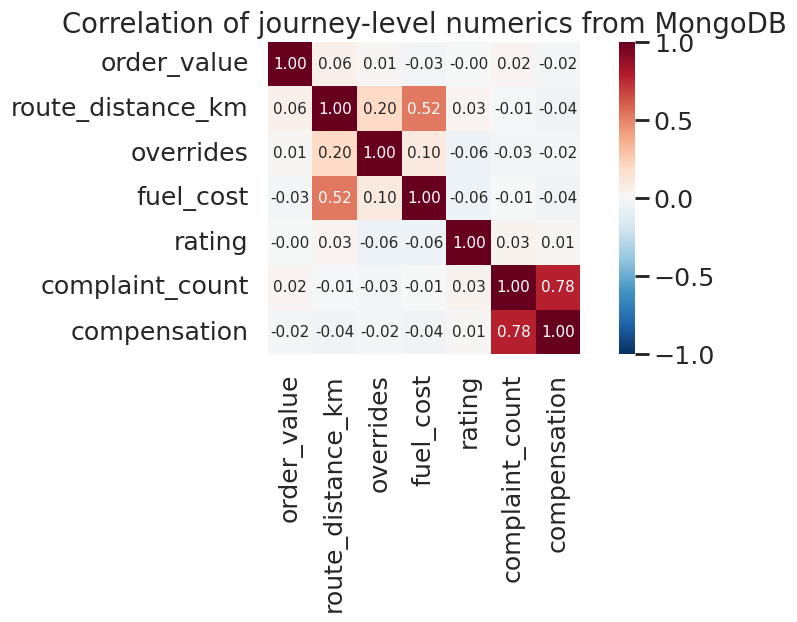

In [33]:
# Plot 1 : correlation heatmap of MongoDB - projected features
num = df_mongo.select_dtypes(include='number')
plt.figure(figsize=(9, 6))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, annot_kws={'size':10})
plt.title('Correlation of journey-level numerics from MongoDB')
plt.tight_layout(); plt.show()

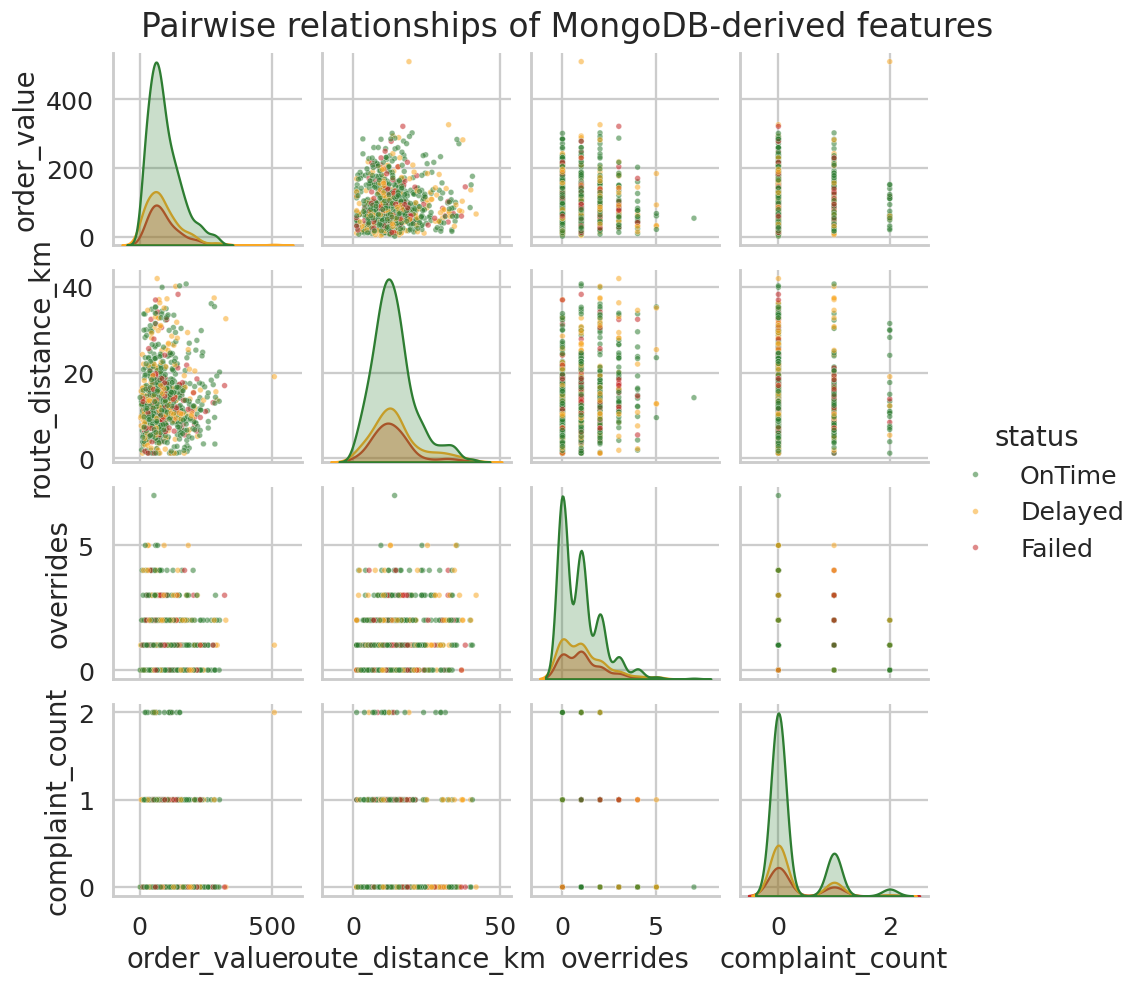

In [34]:
# Plot 2 : pair plot of selected features , coloured by delivery status
subset = df_mongo[['order_value','route_distance_km','overrides',
                   'complaint_count','status']].dropna()
pp = sns.pairplot(subset, hue='status',
                  palette={'OnTime':'#2E7D32','Delayed':'#F9A825','Failed':'#C62828'},
                  plot_kws={'alpha':0.55,'s':14}, diag_kind='kde', height=2.2)
pp.fig.suptitle('Pairwise relationships of MongoDB-derived features', y=1.02)
plt.show()

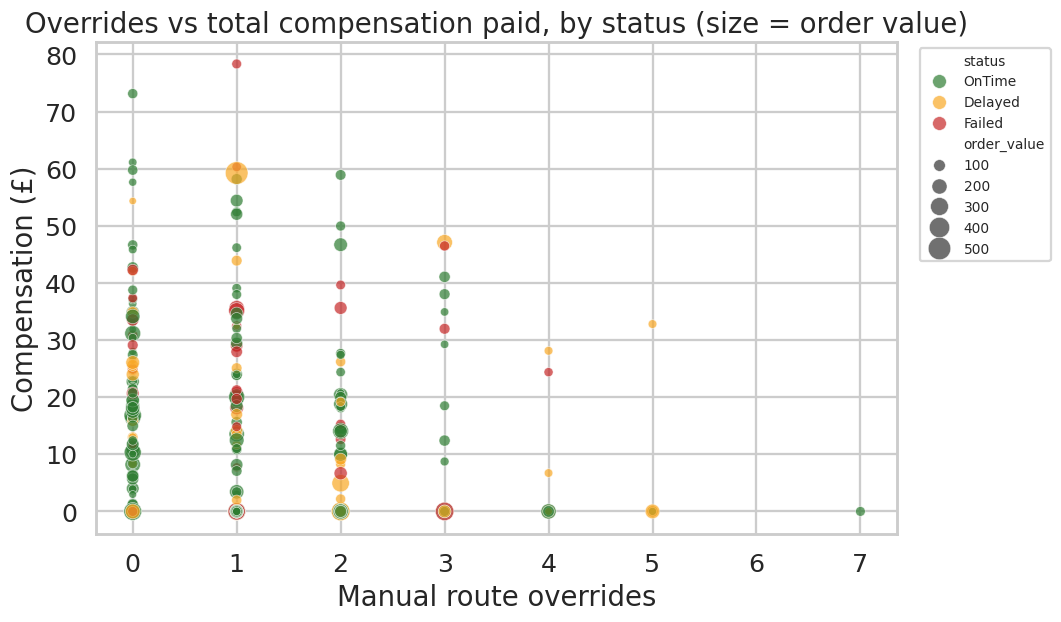

In [35]:
# Plot 3 : scatter — overrides vs compensation , sized by order value
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_mongo, x='overrides', y='compensation',
                hue='status', size='order_value', sizes=(20,220), alpha=0.7,
                palette={'OnTime':'#2E7D32','Delayed':'#F9A825','Failed':'#C62828'}, ax=ax)
ax.set_title('Overrides vs total compensation paid, by status (size = order value)')
ax.set_xlabel('Manual route overrides'); ax.set_ylabel('Compensation (£)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

---
## 9 . Section 3 takeaways

1. **A document model fits NorthStar's analytics needs better than the current relational sprawl .** One read = one journey , with delivery , complaints , incidents and app events alongside . The reconciliation pain the case study describes mostly disappears .
2. **Schema decisions are driven by access patterns** : reference data (customers , drivers , vehicles , hubs) stays normalised because it's slow - changing and shared ; per - journey events are embedded because they are read together .
3. **CRUD and aggregation pipelines** can answer the same business questions Section 1 needed three or four joins for .
4. **Indexes deliver measurable wins .** Adding `ix_zone_status` cut documents - examined dramatically and changed the plan from a `COLLSCAN` to an `IXSCAN` . On Atlas's free - tier latency , this matters even at our small scale; in production it would scale to orders of magnitude .
5. **The same numerical features that drove Sections 1 – 2 surface easily** out of the document model , so reporting tooling does not need a separate data warehouse for these workloads .